In [2]:
import warnings
warnings.filterwarnings('ignore',category=FutureWarning)
import pandas as pd
import os
import seaborn as sns
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np
import matplotlib.pyplot as plt

In [3]:
d1 = pd.read_excel(r"C:\Users\DELL\Desktop\course_prac\ml\Regression_Projects\Refinance_Project\Weekly_Refinance_Volumes_Data.xlsx")

In [4]:
d1.head()

,Date,Week No,Month No,Year,Refinance,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income
0,2018-12-31,1,1,2019,885.0,4.51,1.6,187.901424,1.700000,4.0,2.4,101.008462,101.0012,329495.250000,16027.8
1,2019-01-07,2,1,2019,1094.0,4.51,1.6,187.901424,2.160000,4.0,2.4,101.008462,101.0012,348680.142857,16027.8
2,2019-01-14,3,1,2019,1078.0,4.51,1.6,187.901424,2.195714,4.0,2.4,101.008462,101.0012,322446.857143,16027.8
3,2019-01-21,4,1,2019,1032.0,4.51,1.6,187.901424,1.747143,4.0,2.4,101.008462,101.0012,264000.714286,16027.8
4,2019-01-28,5,2,2019,989.0,4.51,1.5,188.841570,2.168571,3.8,2.4,101.065220,101.0591,251632.285714,16073.8


In [5]:
d1.tail()

,Date,Week No,Month No,Year,Refinance,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income
196,2022-10-02,40,10,2022,NaN,5.405537,9.1,274.253358,2.379681,3.6,2.5,96.600531,105.138462,213138.5625,18423.057143
197,2022-10-09,41,10,2022,NaN,5.405537,9.1,274.253358,2.379681,3.6,2.5,96.600531,105.138462,213138.5625,18423.057143
198,2022-10-16,42,10,2022,NaN,5.405537,9.1,274.253358,2.379681,3.6,2.5,96.600531,105.138462,213138.5625,18423.057143
199,2022-10-23,43,10,2022,NaN,5.405537,9.1,274.253358,2.379681,3.6,2.5,96.600531,105.138462,213138.5625,18423.057143
200,2022-10-30,44,10,2022,NaN,5.405537,9.1,274.253358,2.379681,3.6,2.5,96.600531,105.138462,213138.5625,18423.057143


In [6]:
d1.shape

(201, 15)

In [7]:
d1.columns

Index(['Date', 'Week No', 'Month No', 'Year', 'Refinance', 'Mortgage Rate',
       'Inflation', 'Housing Price Index', 'Treasury Yield',
       'Unemployment Rate', 'GDP', 'Business Confidence Index',
       'Consumer Confidence Index', 'Initial Unemployment Claim',
       'Disposable Income'],
      dtype='object')

In [8]:
d1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Date                        201 non-null    datetime64[ns]
 1   Week No                     201 non-null    int64         
 2   Month No                    201 non-null    int64         
 3   Year                        201 non-null    int64         
 4   Refinance                   188 non-null    float64       
 5   Mortgage Rate               201 non-null    float64       
 6   Inflation                   201 non-null    float64       
 7   Housing Price Index         201 non-null    float64       
 8   Treasury Yield              201 non-null    float64       
 9   Unemployment Rate           201 non-null    float64       
 10  GDP                         201 non-null    float64       
 11  Business Confidence Index   201 non-null    float64       

In [9]:
d1.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,201,2020-11-29 23:24:10.746268672,2018-12-31 00:00:00,2019-12-16 00:00:00,2020-11-30 00:00:00,2021-11-15 00:00:00,2022-10-30 00:00:00,NaN
Week No,201.0,25.756219,1.0,13.0,26.0,38.0,53.0,14.752806
Month No,201.0,6.353234,1.0,3.0,6.0,9.0,12.0,3.371884
Year,201.0,2020.442786,2019.0,2019.0,2020.0,2021.0,2022.0,1.099072
Refinance,188.0,2424.271277,464.0,1729.5,2514.0,2953.5,4636.0,963.107935
Mortgage Rate,201.0,3.661015,2.65,2.98,3.49,4.08,5.81,0.852269
Inflation,201.0,3.925373,0.1,1.5,2.3,6.8,9.1,3.028267
Housing Price Index,201.0,226.880017,187.901424,195.660059,217.835281,254.163779,282.693917,31.316747
Treasury Yield,201.0,1.608493,0.758571,1.174286,1.587143,1.938,3.012,0.514188
Unemployment Rate,201.0,5.270647,3.5,3.6,3.9,6.0,14.7,2.608732


In [10]:
d1.corr()

,Date,Week No,Month No,Year,Refinance,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income
Date,1.000000,0.166146,0.169783,0.967623,-0.123965,0.228560,0.865019,0.971833,0.315295,-0.101655,0.079948,-0.917096,0.353412,-0.133536,0.743464
Week No,0.166146,1.000000,0.996016,-0.079961,0.109263,-0.091306,0.068320,0.104377,-0.203068,-0.012295,0.243292,-0.140269,-0.294710,-0.108628,-0.048424
Month No,0.169783,0.996016,1.000000,-0.076145,0.108547,-0.096064,0.077024,0.112433,-0.199703,-0.021552,0.248530,-0.140870,-0.296843,-0.116258,-0.042619
Year,0.967623,-0.079961,-0.076145,1.000000,-0.151427,0.249639,0.851703,0.953012,0.370420,-0.095542,0.018550,-0.891213,0.430231,-0.104241,0.761469
Refinance,-0.123965,0.109263,0.108547,-0.151427,1.000000,-0.793394,-0.539903,-0.316003,-0.799932,0.640308,-0.077872,0.108996,-0.544023,0.517231,0.163869
Mortgage Rate,0.228560,-0.091306,-0.096064,0.249639,-0.793394,1.000000,0.535009,0.342911,0.802627,-0.447990,-0.109823,-0.285155,0.604182,-0.262231,-0.063043
Inflation,0.865019,0.068320,0.077024,0.851703,-0.539903,0.535009,1.000000,0.940686,0.632321,-0.473086,0.064623,-0.759693,0.574503,-0.401744,0.476062
Housing Price Index,0.971833,0.104377,0.112433,0.953012,-0.316003,0.342911,0.940686,1.000000,0.470021,-0.239176,0.080091,-0.894889,0.456975,-0.240102,0.671053
Treasury Yield,0.315295,-0.203068,-0.199703,0.370420,-0.799932,0.802627,0.632321,0.470021,1.000000,-0.613565,-0.002383,-0.275263,0.725396,-0.476756,0.043985
Unemployment Rate,-0.101655,-0.012295,-0.021552,-0.095542,0.640308,-0.447990,-0.473086,-0.239176,-0.613565,1.000000,-0.263887,-0.098233,-0.452111,0.841997,0.294871


In [11]:
future_data = d1[d1['Refinance'].isna()]

In [12]:
future_data.head()

,Date,Week No,Month No,Year,Refinance,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income
188,2022-08-08,32,8,2022,NaN,5.405537,9.1,274.253358,2.379681,3.6,2.5,96.600531,105.138462,213138.5625,18423.057143
189,2022-08-15,33,8,2022,NaN,5.405537,9.1,274.253358,2.379681,3.6,2.5,96.600531,105.138462,213138.5625,18423.057143
190,2022-08-22,34,8,2022,NaN,5.405537,9.1,274.253358,2.379681,3.6,2.5,96.600531,105.138462,213138.5625,18423.057143
191,2022-08-29,35,8,2022,NaN,5.405537,9.1,274.253358,2.379681,3.6,2.5,96.600531,105.138462,213138.5625,18423.057143
192,2022-09-05,36,9,2022,NaN,5.405537,9.1,274.253358,2.379681,3.6,2.5,96.600531,105.138462,213138.5625,18423.057143


In [13]:
future_data.shape

(13, 15)

In [14]:
base_data = d1[~d1['Refinance'].isna()]

In [15]:
base_data.shape

(188, 15)

In [16]:
base_data.isna().sum()

Date                          0
Week No                       0
Month No                      0
Year                          0
Refinance                     0
Mortgage Rate                 0
Inflation                     0
Housing Price Index           0
Treasury Yield                0
Unemployment Rate             0
GDP                           0
Business Confidence Index     0
Consumer Confidence Index     0
Initial Unemployment Claim    0
Disposable Income             0
dtype: int64

In [17]:
base_data = base_data.drop('Date',axis = 1)

In [18]:
base_data.head()

,Week No,Month No,Year,Refinance,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income
0,1,1,2019,885.0,4.51,1.6,187.901424,1.700000,4.0,2.4,101.008462,101.0012,329495.250000,16027.8
1,2,1,2019,1094.0,4.51,1.6,187.901424,2.160000,4.0,2.4,101.008462,101.0012,348680.142857,16027.8
2,3,1,2019,1078.0,4.51,1.6,187.901424,2.195714,4.0,2.4,101.008462,101.0012,322446.857143,16027.8
3,4,1,2019,1032.0,4.51,1.6,187.901424,1.747143,4.0,2.4,101.008462,101.0012,264000.714286,16027.8
4,5,2,2019,989.0,4.51,1.5,188.841570,2.168571,3.8,2.4,101.065220,101.0591,251632.285714,16073.8


In [19]:
x = base_data.drop('Refinance',axis = 1)
y = base_data['Refinance']

In [20]:
x.head()

,Week No,Month No,Year,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income
0,1,1,2019,4.51,1.6,187.901424,1.700000,4.0,2.4,101.008462,101.0012,329495.250000,16027.8
1,2,1,2019,4.51,1.6,187.901424,2.160000,4.0,2.4,101.008462,101.0012,348680.142857,16027.8
2,3,1,2019,4.51,1.6,187.901424,2.195714,4.0,2.4,101.008462,101.0012,322446.857143,16027.8
3,4,1,2019,4.51,1.6,187.901424,1.747143,4.0,2.4,101.008462,101.0012,264000.714286,16027.8
4,5,2,2019,4.51,1.5,188.841570,2.168571,3.8,2.4,101.065220,101.0591,251632.285714,16073.8


In [21]:
y.head()

0     885.0
1    1094.0
2    1078.0
3    1032.0
4     989.0
Name: Refinance, dtype: float64

In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.05,random_state=42)

In [23]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(178, 13) (10, 13) (178,) (10,)


In [24]:
X_train

,Week No,Month No,Year,Mortgage Rate,Inflation,Housing Price Index,Treasury Yield,Unemployment Rate,GDP,Business Confidence Index,Consumer Confidence Index,Initial Unemployment Claim,Disposable Income
60,9,2,2020,3.49,2.3,198.307483,1.270000,3.5,-5.1,101.184329,101.18050,2.039100e+05,16734.800000
123,19,5,2021,2.98,5.0,239.040006,1.687143,5.8,6.7,99.827589,99.76000,4.813359e+05,17980.600000
42,43,10,2019,3.69,1.8,195.304483,1.620000,3.6,1.9,101.114298,101.10910,1.901723e+05,16373.600000
155,51,12,2021,3.10,7.0,256.671745,1.072857,3.9,6.9,97.734888,97.78466,2.558350e+05,18329.500000
55,4,1,2020,3.65,2.5,196.574056,1.252857,3.5,-5.1,101.632600,101.63750,2.663563e+05,16622.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,2,1,2021,2.67,1.4,219.904811,1.330000,6.4,6.3,99.103413,98.99000,1.041158e+06,19120.300000
14,15,4,2019,4.08,2.0,191.975593,2.094286,3.6,3.2,101.461097,101.46270,1.961966e+05,16110.100000
92,41,10,2020,2.88,1.2,214.573902,1.125714,6.9,4.5,99.138963,99.09532,7.520450e+05,17398.900000
179,23,6,2022,5.23,9.1,272.206761,2.200000,3.6,2.5,96.703655,98.70000,2.060990e+05,18388.735714


In [25]:
y

0       885.0
1      1094.0
2      1078.0
3      1032.0
4       989.0
        ...  
183     464.0
184     628.0
185     794.0
186     805.0
187     891.0
Name: Refinance, Length: 188, dtype: float64

In [26]:
y_test

183     464.0
162    2068.0
18     1691.0
15     1789.0
67     4325.0
108    4636.0
45     2325.0
76     3411.0
16     1967.0
146    2805.0
Name: Refinance, dtype: float64

In [27]:
from sklearn.linear_model import LinearRegression
ln=LinearRegression()
ln.fit(X_train,y_train)   #-- Training the model with training data
ln.predict(X_test)

array([1126.74075232, 2097.58964429, 1671.63418666, 1761.48895014,
       3860.3637722 , 3294.45880973, 2291.16983041, 3489.47023178,
       1471.02406654, 2425.32370133])

In [28]:
abs(y_test.values-ln.predict(X_test)).sum() 

np.float64(3533.337311377516)

In [29]:
from sklearn.linear_model import Lasso    #---  L1 Regularisation --
ls=Lasso()
ls.fit(X_train,y_train)
ls.predict(X_test)


C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.436e+07, tolerance: 1.587e+04
  model = cd_fast.enet_coordinate_descent(


array([1109.70691656, 2091.63701083, 1676.68679734, 1770.36556047,
       3868.4257088 , 3297.02091981, 2286.53003221, 3484.87867355,
       1486.47972372, 2432.13234876])

In [30]:
abs(y_test.values-ls.predict(X_test)).sum()

np.float64(3463.5815098297317)

In [31]:
from sklearn.linear_model import Ridge # -- L2 Regularisation
rd=Ridge()
rd.fit(X_train,y_train)
rd.predict(X_test)



array([1093.72967937, 2084.54530092, 1687.03833616, 1781.87989434,
       3874.88600481, 3298.47370123, 2277.13792231, 3487.51015187,
       1501.86714445, 2436.38937579])

In [32]:
abs(y_test.values-rd.predict(X_test)).sum()

np.float64(3403.112753076246)

In [33]:
def table_validation():
  validation_table = []
  for i in [LinearRegression,Lasso,Ridge]:
    rd = i()
    rd.fit(X_train,y_train)
    rd.predict(X_test)

    mae = mean_absolute_error(y_test.values,rd.predict(X_test))
    mse = mean_squared_error(y_test.values,rd.predict(X_test))
    rmse = np.sqrt(mean_squared_error(y_test.values,rd.predict(X_test)))
    mape=(((abs(y_test.values-rd.predict(X_test))/y_test.values)*100).sum())*(1/y_test.shape[0])
    rsquare=r2_score(y_test.values,rd.predict(X_test))
    validation_table.append([i,mae,mse,rmse,mape,rsquare])

  validation_table = pd.DataFrame(validation_table)
  validation_table.columns = ['model name','mae','mse','rmse','mape','rsquare']
  return validation_table

In [34]:
tv = table_validation()

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.436e+07, tolerance: 1.587e+04
  model = cd_fast.enet_coordinate_descent(


In [35]:
tv

,model name,mae,mse,rmse,mape,rsquare
0,<class 'sklearn.linear_model._base.LinearRegre...,353.333731,285430.060980,534.256550,22.913252,0.804494
1,<class 'sklearn.linear_model._coordinate_desce...,346.358151,279624.131914,528.794981,22.317342,0.808471
2,<class 'sklearn.linear_model._ridge.Ridge'>,340.311275,274884.576273,524.294360,21.749771,0.811717


In [36]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import BaggingRegressor

In [37]:
def model_validation(method,X_train,X_test,y_train,y_test):
    validation_table=[]
    models=[LinearRegression,Lasso,Ridge,DecisionTreeRegressor,RandomForestRegressor,BaggingRegressor]
    for i in models:
        rd=i()
        rd.fit(X_train,y_train)
        if method=="train":
            rd.predict(X_train)
            mae=mean_absolute_error(y_train.values,rd.predict(X_train))
            mse=mean_squared_error(y_train.values,rd.predict(X_train))
            rmse=np.sqrt(mean_squared_error(y_train.values,rd.predict(X_train)))
            mape=(((abs(y_train.values-rd.predict(X_train))/y_train.values)*100).sum())*(1/y_train.shape[0])
            rsquare=r2_score(y_train.values,rd.predict(X_train))
            validation_table.append([i,mae,mse,rmse,mape,rsquare])
        
        
        else:  #-- Predict
            rd.predict(X_test)
            mae=mean_absolute_error(y_test.values,rd.predict(X_test))
            mse=mean_squared_error(y_test.values,rd.predict(X_test))
            rmse=np.sqrt(mean_squared_error(y_test.values,rd.predict(X_test)))
            mape=(((abs(y_test.values-rd.predict(X_test))/y_test.values)*100).sum())*(1/y_test.shape[0])
            rsquare=r2_score(y_test.values,rd.predict(X_test))
            validation_table.append([i,mae,mse,rmse,mape,rsquare])
            
    validation_table=pd.DataFrame(validation_table)
    validation_table.columns=["model name","mae","mse","rmse","mape","rsquare"]
    return validation_table

In [38]:
pd.options.display.float_format = '{:0.2f}'.format

In [39]:
validation_table_train = model_validation('train',X_train,X_test,y_train,y_test)

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.436e+07, tolerance: 1.587e+04
  model = cd_fast.enet_coordinate_descent(


In [40]:
validation_table_train

,model name,mae,mse,rmse,mape,rsquare
0,<class 'sklearn.linear_model._base.LinearRegre...,319.12,173506.21,416.54,17.03,0.81
1,<class 'sklearn.linear_model._coordinate_desce...,319.23,173567.94,416.61,17.05,0.81
2,<class 'sklearn.linear_model._ridge.Ridge'>,320.51,173833.87,416.93,17.14,0.81
3,<class 'sklearn.tree._classes.DecisionTreeRegr...,0.00,0.00,0.00,0.00,1.00
4,<class 'sklearn.ensemble._forest.RandomForestR...,95.45,21014.53,144.96,4.77,0.98
5,<class 'sklearn.ensemble._bagging.BaggingRegre...,108.26,32452.21,180.14,5.66,0.96


In [41]:
validation_table_test = model_validation('test',X_train,X_test,y_train,y_test)

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.436e+07, tolerance: 1.587e+04
  model = cd_fast.enet_coordinate_descent(


In [42]:
validation_table_test

,model name,mae,mse,rmse,mape,rsquare
0,<class 'sklearn.linear_model._base.LinearRegre...,353.33,285430.06,534.26,22.91,0.80
1,<class 'sklearn.linear_model._coordinate_desce...,346.36,279624.13,528.79,22.32,0.81
2,<class 'sklearn.linear_model._ridge.Ridge'>,340.31,274884.58,524.29,21.75,0.81
3,<class 'sklearn.tree._classes.DecisionTreeRegr...,238.00,150362.20,387.77,8.25,0.90
4,<class 'sklearn.ensemble._forest.RandomForestR...,238.57,117593.23,342.92,12.64,0.92
5,<class 'sklearn.ensemble._bagging.BaggingRegre...,240.33,107606.34,328.03,12.25,0.93


### Model Evaluation Summary

#### Linear Regression, Lasso & Ridge
- Train and Test R² are around **0.80 - 0.81**.
- Performance is consistent on both datasets, indicating **good generalization**.
- However, the overall predictive power is moderate, suggesting that the relationship may be non-linear.
- Hyperparameter tuning will be performed to check for further improvements.

#### Decision Tree Regressor
- Train R² = **1.00** and Train MSE = **0**, indicating the model has perfectly memorized the training data.
- Test R² dropped to **0.89**, showing **significant overfitting**.
- Hyperparameter tuning is required to control model complexity and improve generalization.

#### Random Forest Regressor
- Train R² = **0.98** and Test R² = **0.91**.
- Training error is much lower than testing error, indicating **mild overfitting**.
- Hyperparameter tuning is required to optimize model performance and reduce overfitting.

#### Bagging Regressor
- Train R² = **0.97** and Test R² = **0.92**.
- The model generalizes better than Decision Tree and Random Forest but still shows a small train-test gap.
- Hyperparameter tuning will be performed to further improve robustness and predictive accuracy.

### Conclusion
Tree-based models outperform linear models on this dataset. However, the presence of train-test performance gaps indicates the need for **Hyperparameter Tuning** to obtain the optimal model configuration and improve generalization on unseen data.

## The models are working good on the training data but not working well on the testing data, so we need to do further Processing
##### we need to check multicollinearity, if the features are highly correlated, we need to remove one feature from the highly correlated features
##### By Using Lasso regression model , we can check the features coefficients values, if the coeffis having 0 values, we can remove them from the model building


In [43]:
linreg = LinearRegression()
linreg.fit(X_train,y_train)
linreg_prediction = linreg.predict(X_test)

r_squared = r2_score(y_test,linreg_prediction)
print("R squared Error on test set : ", r_squared)


coefficient_df = pd.DataFrame()
coefficient_df['column_names'] = X_train.columns
coefficient_df['coefficient_values_lr'] = pd.DataFrame(linreg.coef_)
print(coefficient_df)

coefficient_df.to_csv('coeff_values',index = False)
plt.rcParams['figure.figsize'] = (15,6)


R squared Error on test set :  0.8044941586728327
                  column_names  coefficient_values_lr
0                      Week No                 -67.93
1                     Month No                 319.96
2                         Year                 618.99
3                Mortgage Rate                -543.42
4                    Inflation                 -55.37
5          Housing Price Index                 -20.44
6               Treasury Yield                -478.35
7            Unemployment Rate                  28.73
8                          GDP                  -3.99
9    Business Confidence Index                 -26.96
10   Consumer Confidence Index                   3.27
11  Initial Unemployment Claim                   0.00
12           Disposable Income                  -0.04


<BarContainer object of 13 artists>

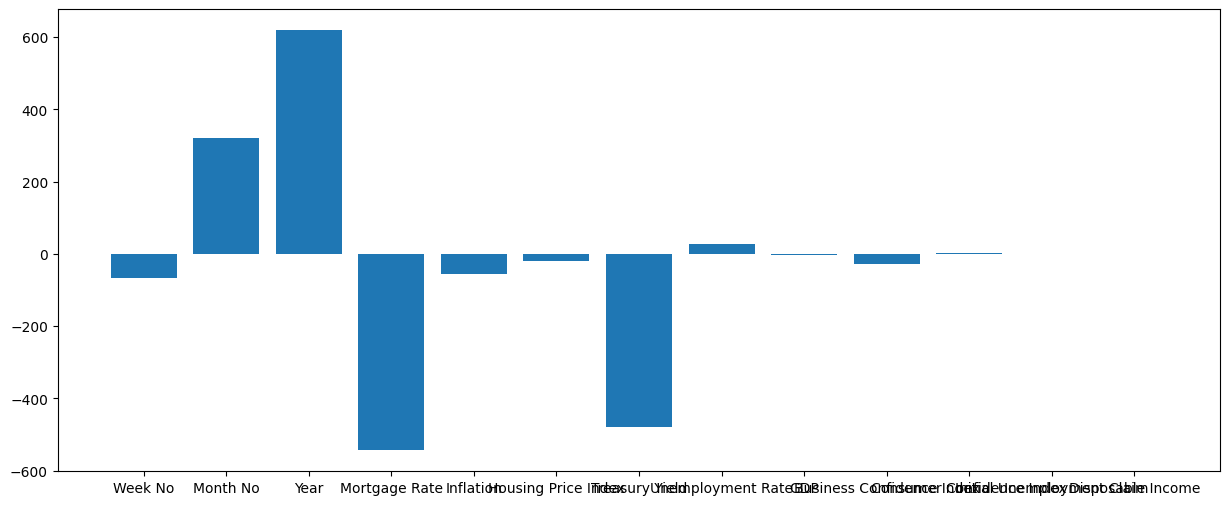

In [44]:
plt.bar(coefficient_df['column_names'],coefficient_df
        ['coefficient_values_lr'])

In [45]:
coefficient_df = pd.DataFrame()

In [46]:
coefficient_df['column_names'] = X_train.columns

In [47]:
coefficient_df

,column_names
0,Week No
1,Month No
2,Year
3,Mortgage Rate
4,Inflation
5,Housing Price Index
6,Treasury Yield
7,Unemployment Rate
8,GDP
9,Business Confidence Index


In [49]:
coefficient_df['Coefficient_Value'] = pd.Series(linreg.coef_)
print(coefficient_df)

                  column_names  Coefficient_Value
0                      Week No             -67.93
1                     Month No             319.96
2                         Year             618.99
3                Mortgage Rate            -543.42
4                    Inflation             -55.37
5          Housing Price Index             -20.44
6               Treasury Yield            -478.35
7            Unemployment Rate              28.73
8                          GDP              -3.99
9    Business Confidence Index             -26.96
10   Consumer Confidence Index               3.27
11  Initial Unemployment Claim               0.00
12           Disposable Income              -0.04


In [50]:
pd.Series(linreg.coef_)

0     -67.93
1     319.96
2     618.99
3    -543.42
4     -55.37
5     -20.44
6    -478.35
7      28.73
8      -3.99
9     -26.96
10      3.27
11      0.00
12     -0.04
dtype: float64

In [51]:
linreg.intercept_

np.float64(-1238174.6257857531)

R squared Error on test set :  0.633969771215912


<BarContainer object of 13 artists>

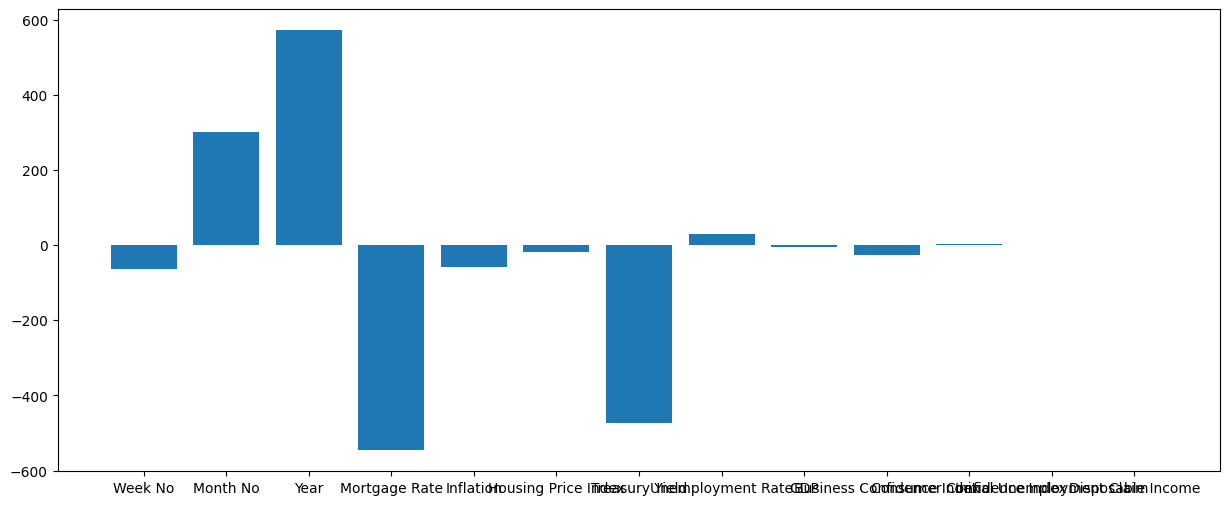

In [58]:
from sklearn.linear_model import Ridge

# Train the model
ridgeRegressor = Ridge(alpha = 0.5) #here setting alpha is nothing but lambda in the formula
ridgeRegressor.fit(X_train, y_train)
y_predicted_ridge = ridgeRegressor.predict(X_test)

# calculating R_square
R_squared = r2_score(y_predicted_ridge,y_test)
print("R squared Error on test set : ", R_squared)

coefficient_df['Coefficient_Value_ridge'] = pd.Series(ridgeRegressor.coef_)
#print(coefficient_df.head)
coefficient_df.to_csv('coeff_values.csv',index=False)
plt.rcParams["figure.figsize"] = (15,6)
 
plt.bar(coefficient_df["column_names"],coefficient_df["Coefficient_Value_ridge"])

R squared Error on test set :  0.6340601745017338


C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.436e+07, tolerance: 1.587e+04
  model = cd_fast.enet_coordinate_descent(


<BarContainer object of 13 artists>

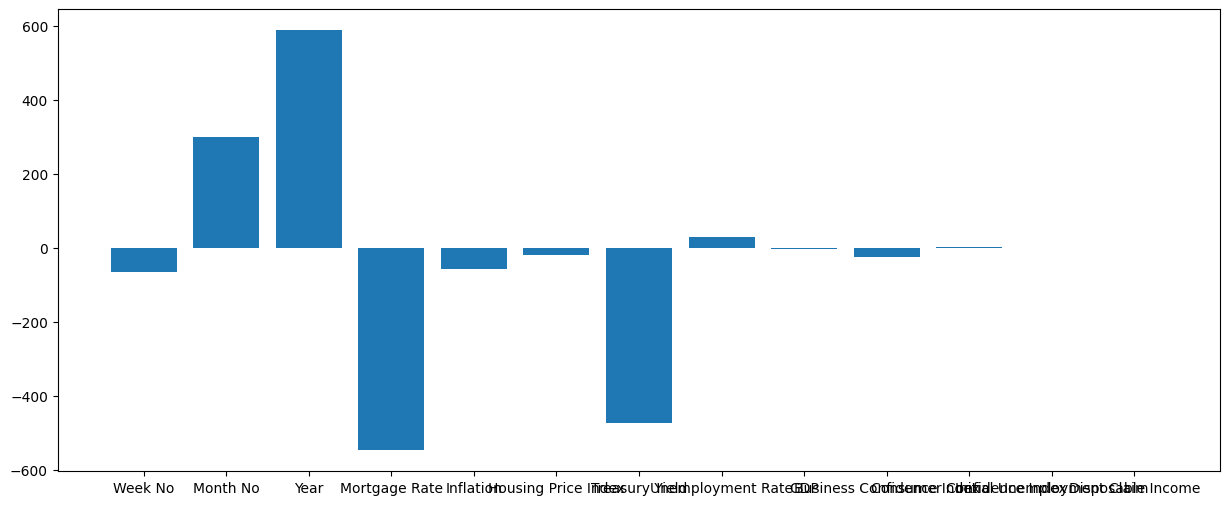

In [59]:
# import Lasso regression from sklearn library
from sklearn.linear_model import Lasso

# Train the model
lassoRegressor = Lasso(alpha = 1) #here setting alpha is nothing but lambda in the formula
lassoRegressor.fit(X_train, y_train)
y_predicted_lasso = lassoRegressor.predict(X_test)

# calculating Mean Squared Error (mse)
R_squared = r2_score(y_predicted_lasso,y_test)
print("R squared Error on test set : ", R_squared)

coefficient_df["column_names"] = X_train.columns
coefficient_df['Coefficient_Value_lasso'] = pd.Series(lassoRegressor.coef_)
#print(coefficient_df.head)
#coefficient_df.to_csv('coeff_values.csv',index=False)

plt.rcParams["figure.figsize"] = (15,6)
 
plt.bar(coefficient_df["column_names"],coefficient_df["Coefficient_Value_lasso"])

In [65]:
coefficient_df = coefficient_df.drop('Column_Name',axis = 1)

In [66]:
coefficient_df

,column_names,Coefficient_Value,Coefficient_Value_ridge,Coefficient_Value_lasso
0,Week No,-67.93,-64.36,-63.60
1,Month No,319.96,301.03,298.89
2,Year,618.99,571.35,588.68
3,Mortgage Rate,-543.42,-546.08,-546.69
4,Inflation,-55.37,-59.72,-56.45
5,Housing Price Index,-20.44,-18.53,-19.22
6,Treasury Yield,-478.35,-474.08,-472.54
7,Unemployment Rate,28.73,28.68,29.09
8,GDP,-3.99,-3.97,-3.92
9,Business Confidence Index,-26.96,-27.65,-24.82


In [67]:
lasso_coeff_zero=[] 

In [68]:
index = len(coefficient_df.Coefficient_Value_lasso)

In [69]:
index

13

In [71]:
i = 0
while i < index:
  if coefficient_df.Coefficient_Value_lasso[i] == 0:
    value = coefficient_df.column_names[i]
    lasso_coeff_zero.append(value)
  i = i+1
lasso_coeff_zero

[]

In [72]:
len(lasso_coeff_zero)

0

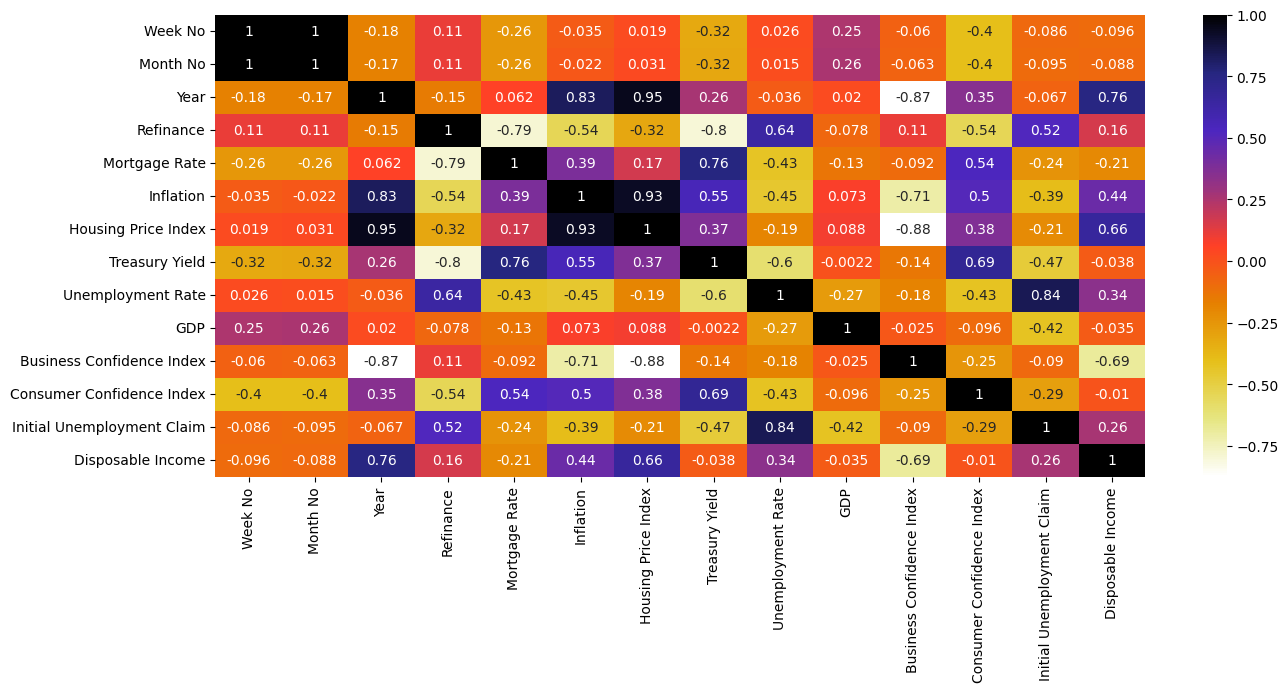

In [73]:
import seaborn as sns
plt.Figure(figsize=(12,6))

cor = base_data.corr()
sns.heatmap(cor,annot = True,cmap = plt.cm.CMRmap_r)
plt.show()